<a href="https://colab.research.google.com/github/hsmu-jeongeun/medical-data-analysis/blob/main/06_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 1 : 모델 성능 평가
- 사이킷런 유방암 데이터셋 사용
- 랜덤 포레스트 알고리즘 사용하여 분류

In [1]:
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
bc = datasets.load_breast_cancer()
X = bc.data
y = bc.target
bc.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [4]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=1000)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000)

In [5]:
y_prop = model.predict_proba(X_test)
y_prop[0:5]

array([[0.223, 0.777],
       [0.666, 0.334],
       [0.004, 0.996],
       [0.007, 0.993],
       [0.242, 0.758]])

In [6]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prop[:,1])

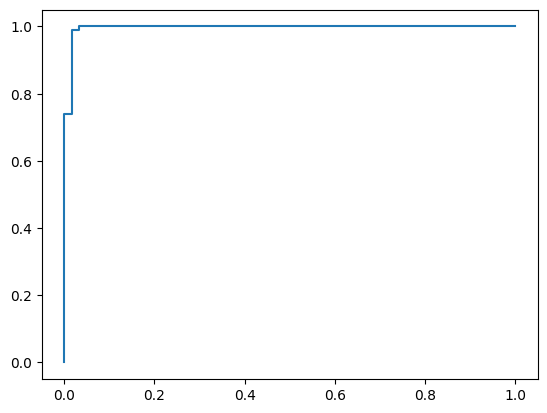

In [7]:
from matplotlib import pyplot as plt
plt.plot(fpr, tpr)
plt.show()

In [8]:
from sklearn.metrics import auc
auc(fpr, tpr)

np.float64(0.9954954954954955)

In [9]:
from sklearn.svm import SVC
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [10]:
y_prop_svm = model.predict_proba(X_test)
y_prop_svm[0:5]

array([[0.15709001, 0.84290999],
       [0.57793563, 0.42206437],
       [0.0260191 , 0.9739809 ],
       [0.03332831, 0.96667169],
       [0.08571089, 0.91428911]])

In [11]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prop_svm[:,1])
auc(fpr, tpr)

np.float64(0.9879879879879879)

- SVM과 Randomforest 모델 중 (SVM / Randomforest)모델의 성능이 더 높다.